1. Initialisation

In [74]:
import os, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import pystac_client
import rasterio
from pyproj import CRS as ProjCRS
from pyproj import Transformer
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from rasterio.crs import CRS as RioCRS
import hashlib

print("Imports successful.")


Imports successful.


2. EMVI header reader

In [67]:
DTYPE_MAP = {
    1: np.uint8,  2: np.int16,   3: np.int32,  4: np.float32,
    5: np.float64, 6: np.complex64, 9: np.complex128,
    12: np.uint16, 13: np.uint32, 14: np.int64, 15: np.uint64,
}                                                                                       # Mapping of ENVI data type codes to NumPy dtypes. This is used to determine how to read the binary data based on the metadata in the header file.

def parse_envi_header(hdr_path: str) -> dict:                                           # Parses ENVI header file and returns metadata as a dictionary.
    meta = {}
    text = Path(hdr_path).read_text(errors="replace")                                   # Read the content of the header file as text, replacing any errors.
    text = re.sub(r"\{([^}]*)\}",                                                       # Use regular expression to find all occurrences of text enclosed in curly braces and replace them with a single line version.
                  lambda m: "{" + m.group(1).replace("\n", " ") + "}", text)            # This ensures that multi-line values in the header are treated as single lines.
    for line in text.splitlines():                                                      # Iterate through each line of the header text.
        line = line.strip()                                                             # Remove leading and trailing whitespace from the line.
        if "=" not in line or line.startswith(";"):                                     # Skip lines that do not contain an equals sign or that start with a semicolon (comments).
            continue
        key, _, val = line.partition("=")                                               # Split the line into key and value based on the first occurrence of the equals sign.
        key, val = key.strip().lower(), val.strip()
        if val.startswith("{") and val.endswith("}"):
            items = [v.strip() for v in val[1:-1].split(",") if v.strip()]              # Split the value by commas, strip whitespace from each item, and filter out any empty items.
            try:    val = [float(v) for v in items]                                     # Attempt to convert each item in the list to a float. If successful, val becomes a list of floats.
            except: val = items
        else:
            try:    val = int(val)
            except:
                try:    val = float(val)
                except: pass
        meta[key] = val
    return meta

def find_data_file(hdr_path: str) -> str:                                               # Given the path to an ENVI header file, this function attempts to find the corresponding data file by checking for common extensions.
    base = os.path.splitext(hdr_path)[0]                                                # Remove the file extension from the header path to get the base name.
    for ext in ("", ".bsq", ".img", ".raw", ".dat"):
        if os.path.isfile(base + ext):
            return base + ext
    raise FileNotFoundError(f"No data file found for {hdr_path}")


class HyperspectralCube:                                                                # This class represents a hyperspectral data cube, providing methods to load the data and access its properties.
    def __init__(self, hdr_path: str):                                                  # Initializes the HyperspectralCube object by loading metadata from the ENVI header and setting up the data path.
        self.hdr_path  = str(hdr_path)
        self.meta      = parse_envi_header(self.hdr_path)
        self.data_path = find_data_file(self.hdr_path)
        self._wl_are_indices = False                                                    # Flag to indicate whether wavelengths are just band indices (used if wavelength info is missing).
        self._load()

    def _load(self):
        m = self.meta
        self.samples = int(m["samples"])
        self.lines   = int(m["lines"])
        self.bands   = int(m["bands"])
        dtype        = DTYPE_MAP.get(int(m.get("data type", 4)), np.float32)            # Determine the NumPy data type to use for reading the binary data based on the "data type" specified in the header. Default to np.float32 if not specified or unrecognized.
        bo           = ">" if int(m.get("byte order", 0)) == 1 else "<"                 # Determine the byte order for reading the binary data based on the "byte order" specified in the header. ">" indicates big-endian and "<" indicates little-endian.
        dt           = np.dtype(f"{bo}{np.dtype(dtype).str[1:]}")                       # Create a NumPy dtype object that combines the byte order and the data type. This will be used to read the binary data correctly.
        self.data    = np.memmap(self.data_path, dtype=dt, mode="r",                    # Load the binary data into memory as a memory-mapped array.
                                 shape=(self.bands, self.lines, self.samples))
        wl = m.get("wavelength")
        if isinstance(wl, list) and len(wl) == self.bands:                              # If the "wavelength" metadata is a list of the same length as the number of bands, use it as the wavelengths for each band.
            self.wavelengths = np.array(wl, dtype=np.float64)                           # Convert the list of wavelengths to a NumPy array of type float64 for easier numerical operations.
        else:
            self.wavelengths = np.arange(1, self.bands + 1, dtype=np.float64)           # If wavelength information is missing or invalid, create a default array of band indices (1-based) as the wavelengths. This allows the code to still function even if the actual wavelengths are not provided.
            self._wl_are_indices = True

        ign = m.get("data ignore value")                                                # Get the "data ignore value" from the metadata, which indicates the value used to represent no-data or invalid data in the dataset.
        self.ignore_value  = float(ign) if ign is not None else None
        self.scale_factor  = float(m.get("reflectance scale factor", 1.0))              # Get the "reflectance scale factor" from the metadata, which is used to scale the raw data values to reflectance. Default to 1.0 if not specified.

        db = m.get("default bands")
        if isinstance(db, list) and len(db) >= 3:
            self.default_rgb = [int(db[0])-1, int(db[1])-1, int(db[2])-1]
        else:
            s = max(1, self.bands // 4)                                                 # If "default bands" is not provided or invalid, calculate default RGB band indices by taking evenly spaced bands across the spectrum. The red channel is set to the band at 1/4 of the total bands, green at 1/2, and blue at 3/4, ensuring that they are within the valid range of band indices.
            self.default_rgb = [min(s, self.bands-1),
                                 min(2*s, self.bands-1),
                                 min(3*s, self.bands-1)]
        self.default_wl = [self.wavelengths[i] for i in self.default_rgb]

    # ── helpers ───────────────────────────────────────────────────────────────

    def nodata_mask(self, arr: np.ndarray) -> np.ndarray:                               # This method creates a boolean mask for the input array where True indicates the presence of no-data values. If the ignore_value is None, it returns an array of False (indicating no no-data values). Otherwise, it uses np.isclose to compare the input array with the ignore_value, allowing for a small tolerance to account for floating-point precision issues.
        if self.ignore_value is None:
            return np.zeros(arr.shape, dtype=bool)                                      # If no ignore_value is defined, return an array of False (indicating no no-data values).
        return np.isclose(arr, self.ignore_value, rtol=0, atol=0.5)                     # Create a boolean mask where True indicates values that are close to the ignore_value, with a tolerance of 0.5. This accounts for potential floating-point precision issues when comparing values.

    def band_float(self, idx: int) -> np.ndarray:
        """Return band as float32 ndarray with no-data → NaN."""
        raw  = np.array(self.data[idx], dtype=np.float32)
        mask = self.nodata_mask(raw)                                                    # Create a boolean mask for the raw band data where True indicates no-data values.
        raw[mask] = np.nan                                                              # Replace no-data values in the raw band data with NaN (Not a Number) to facilitate further processing and visualization.
        return raw

    def nearest_band(self, wavelength_nm: float) -> int:
        """Return 0-based index of the band closest to wavelength_nm."""
        return int(np.argmin(np.abs(self.wavelengths - wavelength_nm)))                 # Calculate the absolute difference between the input wavelength and the wavelengths of all bands, find the index of the minimum difference, and return it as the nearest band index.

    def summary(self):                                                                  # This method prints a summary of the hyperspectral cube, including the file name, dimensions, wavelength range, no-data value, scale factor, and default RGB band indices. It uses the wavelengths array to display the range of wavelengths covered by the dataset.
        wl = self.wavelengths
        print(f"  File   : {Path(self.hdr_path).name}")                                 # Print the name of the header file, which is typically the same as the data file but with a .hdr extension.
        print(f"  Size   : {self.samples} × {self.lines} pixels × {self.bands} bands")
        print(f"  WL     : {wl[0]:.1f} – {wl[-1]:.1f}"
              f" {'nm' if not self._wl_are_indices else '(band indices)'}")
        print(f"  No-data: {self.ignore_value}")
        print(f"  Scale  : {self.scale_factor}")
        print(f"  RGB def: bands {[b+1 for b in self.default_rgb]} (1-based)")

print("Classes defined.")


Classes defined.


3. Load a cube

In [68]:
# ── auto-discover ──────────────────────────────────────────────────────────────
search_dir = Path("data/images")
found = sorted(search_dir.glob("*.hdr")) if search_dir.is_dir() else []             # Search for .hdr files in the specified directory. If the directory does not exist, found will be an empty list.

if len(found) == 1:
    HDR_PATH = str(found[0])
    print(f"Auto-selected: {HDR_PATH}")
elif len(found) > 1:
    print("Multiple .hdr files found – set HDR_PATH manually:")
    for i, p in enumerate(found):
        print(f"  [{i}] {p}")
    HDR_PATH = str(found[0])            # ← change index or set path directly

cube = HyperspectralCube(HDR_PATH)
cube.summary()


Multiple .hdr files found – set HDR_PATH manually:
  [0] data\images\221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
  [1] data\images\221000_Odra_HS_Blok_A_013_VS_join_atm.hdr
  [2] data\images\221000_Odra_HS_Blok_A_015_VS_join_atm.hdr
  File   : 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
  Size   : 2001 × 4300 pixels × 456 bands
  WL     : 414.1 – 2498.9 nm
  No-data: 15000.0
  Scale  : 10000.0
  RGB def: bands [75, 46, 19] (1-based)


4. Stretch utiliies

In [69]:
def linear_stretch(band: np.ndarray,
                   pct_lo: float = 2.0,
                   pct_hi: float = 98.0) -> np.ndarray:
    """Percentile linear stretch → [0, 1] float32; NaN pixels → 0."""
    valid = band[np.isfinite(band)]                                                   # Extract the valid (finite) pixel values from the input band for calculating the stretch parameters. This excludes any NaN or infinite values that may be present in the band.
    if valid.size == 0:
        return np.zeros_like(band, dtype=np.float32)                                  # If there are no valid pixels, return an array of zeros with the same shape as the input band.
    lo, hi = np.percentile(valid, [pct_lo, pct_hi])                                   # Calculate the lower and upper percentile values based on the specified pct_lo and pct_hi parameters. These values will be used to define the range for the linear stretch.
    if hi == lo:
        hi = lo + 1.0
    out = np.clip((band - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)               # Apply the linear stretch to the input band by scaling the pixel values based on the calculated lo and hi percentiles. The result is clipped to the range [0, 1] and converted to float32. NaN pixels will remain NaN after this operation.
    out[~np.isfinite(band)] = 0.0                                                     # Set any non-finite pixels (NaN or infinite) in the output to 0.0, ensuring that no-data values are represented as black in the stretched image.
    return out

def make_rgb(cube: HyperspectralCube,
             r_idx: int = cube.default_rgb[0], g_idx: int = cube.default_rgb[1], b_idx: int = cube.default_rgb[2],
             pct: tuple = (2, 98)) -> np.ndarray:
    """
    Build a (lines, samples, 3) uint8 composite from three band indices.
    stretch: 'linear' | 'histeq'
    """
    channels = []
    for idx in (r_idx, g_idx, b_idx):
        band = cube.band_float(idx)
        s = linear_stretch(band, *pct)
        channels.append(s)
    rgb = np.stack(channels, axis=2)                                                  # Stack the three stretched channels (R, G, B) along the third axis to create a (lines, samples, 3) array representing the RGB composite. Each channel is a 2D array of the same shape as the original bands, and stacking them creates a 3D array where the last dimension corresponds to the color channels.
    return (rgb * 255).astype(np.uint8)

def show_composite(rgb: np.ndarray,
                   title: str = "",
                   band_labels: tuple = (f"{cube.default_wl[0]:.1f} nm", f"{cube.default_wl[1]:.1f} nm", f"{cube.default_wl[2]:.1f} nm"),
                   ax=None,
                   cbar: bool = False):
    """Display a (H, W, 3) uint8 RGB composite with a compact caption."""
    standalone = ax is None                                                           # Check if an Axes object was provided. If not, we are in standalone mode and need to create a new figure and axes for displaying the image.
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
    ax.imshow(rgb, interpolation="nearest")                                           # Display the RGB composite image on the axes using imshow with nearest neighbor interpolation to preserve the pixelated appearance.
    ax.set_title(title, fontsize=11, pad=6)
    caption = f"R={band_labels[0]}  G={band_labels[1]}  B={band_labels[2]}"
    ax.set_xlabel(caption, fontsize=8, color="#555")
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    if standalone:
        plt.tight_layout()
        plt.show()

print("Stretch utilities defined.")


Stretch utilities defined.


5. False-color composite

R → band  134  (839.3 nm)
G → band   78  (660.3 nm)
B → band   44  (551.6 nm)


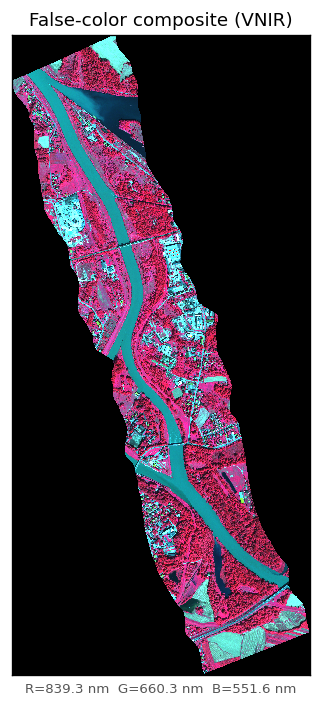

In [70]:
# ── VNIR wavelengths ─────────────────────────────────────────
R_NM = 840.0    # NIR band
G_NM = 660.0    # Red band
B_NM = 550.0    # Green band

# ─────────────────────────────────────────────────────────────────────────────
r = cube.nearest_band(R_NM)
g = cube.nearest_band(G_NM)
b = cube.nearest_band(B_NM)

print(f"R → band {r+1:4d}  ({cube.wavelengths[r]:.1f} nm)")
print(f"G → band {g+1:4d}  ({cube.wavelengths[g]:.1f} nm)")
print(f"B → band {b+1:4d}  ({cube.wavelengths[b]:.1f} nm)")

rgb_vnir = make_rgb(cube, r, g, b)
show_composite(rgb_vnir,
    title="False-color composite (VNIR)",
    band_labels=(f"{cube.wavelengths[r]:.1f} nm", f"{cube.wavelengths[g]:.1f} nm", f"{cube.wavelengths[b]:.1f} nm"))

6. Water indices - Setup

In [71]:
# ── Water Quality Indices ──────────────────────────────────────────────────────
# Each index is computed from reflectance (raw / scale_factor).
# Bands are selected by nearest-wavelength lookup so the cell works
# with any hyperspectral cube that covers the required wavelength range.

# ── Target wavelengths ────────────────────────────────────────────────────────
# Chlorophyll-a:  NDCI (Mishra & Mishra 2012)
CHL_RE_NM  = 709.0   # Red-edge / Chl-a fluorescence shoulder
CHL_RED_NM = 665.0   # Chlorophyll-a absorption minimum

# DOC / CDOM proxy: blue-to-green absorption ratio
# CDOM absorbs strongly at 443 nm → lower R443 → higher DOC signal
DOC_GREEN_NM = 555.0  # Reference green channel
DOC_BLUE_NM  = 443.0  # CDOM absorption peak

# Turbidity proxy: NIR / Red backscattering ratio
# Suspended particles raise NIR reflectance relative to red
TURB_NIR_NM = 745.0   # NIR reference
TURB_RED_NM = 665.0   # Red channel


def get_refl(cube, wavelength_nm: float) -> "np.ndarray":
    """Return a band as reflectance [0, 1] float32 with no-data → NaN."""
    idx = cube.nearest_band(wavelength_nm)
    return cube.band_float(idx) / cube.scale_factor


def ndvi_like(a: "np.ndarray", b: "np.ndarray") -> "np.ndarray":
    """(a - b) / (a + b) with zero-denominator → NaN."""
    denom = a + b
    denom = np.where(denom == 0, np.nan, denom)
    return (a - b) / denom


def band_ratio(a: "np.ndarray", b: "np.ndarray") -> "np.ndarray":
    """a / b with zero-denominator → NaN."""
    b_safe = np.where(b == 0, np.nan, b)
    return a / b_safe


# ── Helper: plot one index map with a labelled colorbar ──────────────────────
def plot_index(ax, data, title, cmap, pct_lo=2, pct_hi=98, cbar_label="", cax=None):
    valid = data[np.isfinite(data)]
    vmin  = np.percentile(valid, pct_lo) if valid.size else 0
    vmax  = np.percentile(valid, pct_hi) if valid.size else 1
    im = ax.imshow(data, cmap=cmap, interpolation="nearest",
                   vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9, pad=5)
    ax.axis("off")
    if cax is not None:
        cb = plt.colorbar(im, cax=cax)
    else:
        cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.1)
    cb.set_label(cbar_label, fontsize=8)
    cb.ax.tick_params(labelsize=7)

print("Index utilities defined.")

Index utilities defined.


7. Water indices - Calculation

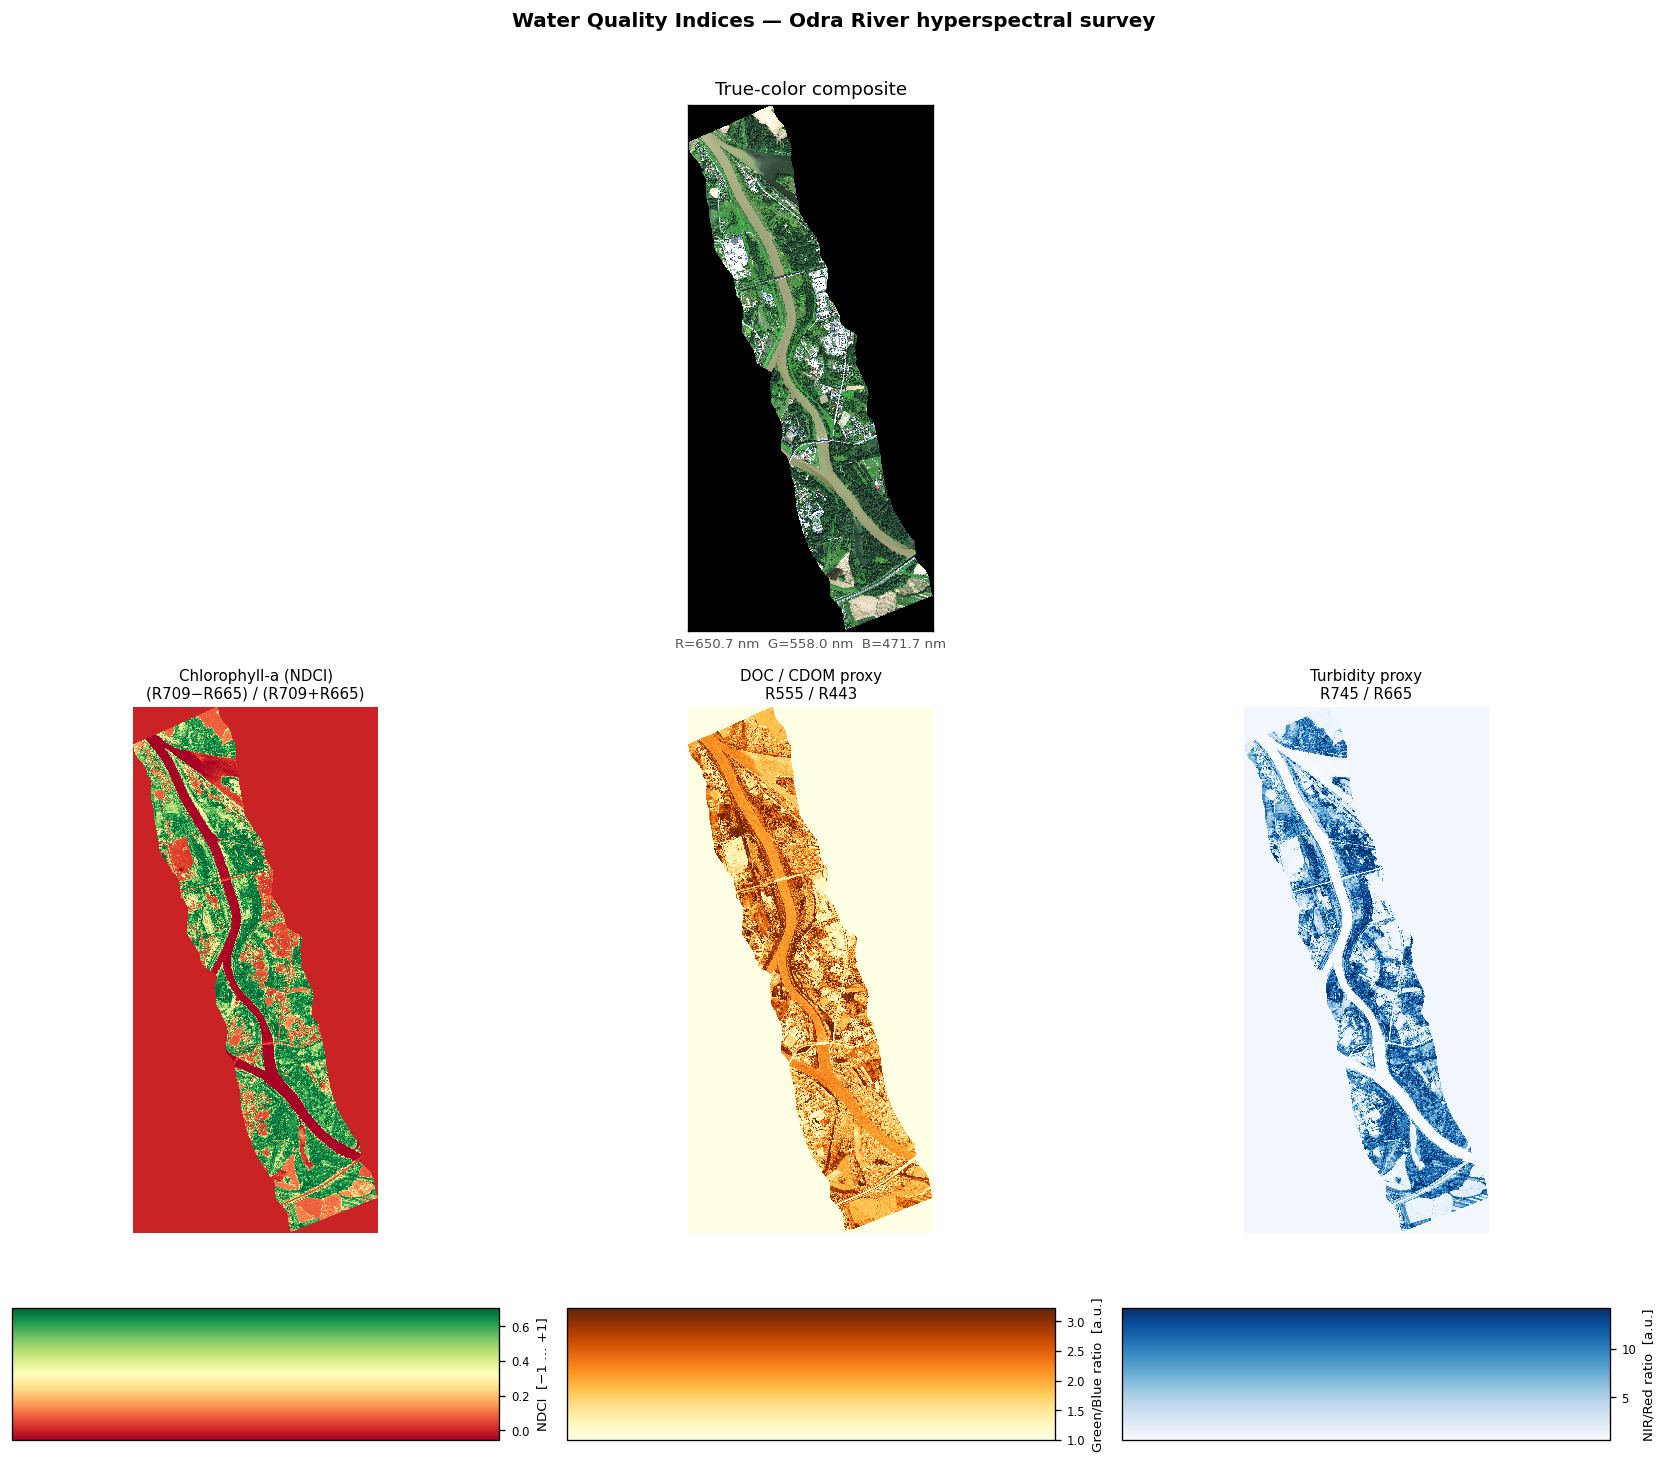

Chl-a (NDCI)               min=-0.6878  median=0.0000  max=0.8141  (valid px: 8,603,776)
DOC/CDOM (ratio)           min=0.2985  median=1.0000  max=10.0526  (valid px: 8,603,741)
Turbidity (ratio)          min=-0.0095  median=1.0000  max=25.4944  (valid px: 8,603,775)


In [72]:
# ── 1. Chlorophyll-a: NDCI = (R709 − R665) / (R709 + R665) ──────────────────
r709 = get_refl(cube, CHL_RE_NM)
r665 = get_refl(cube, CHL_RED_NM)
chl_a = ndvi_like(r709, r665)          # range ≈ [-1, +1]; higher → more Chl-a

# ── 2. DOC/CDOM proxy = R555 / R443 ──────────────────────────────────────────
#    CDOM absorbs at 443 nm: where CDOM is high, R443 is low → ratio rises
r555 = get_refl(cube, DOC_GREEN_NM)
r443 = get_refl(cube, DOC_BLUE_NM)
doc  = band_ratio(r555, r443)          # higher → more CDOM / DOC

# ── 3. Turbidity proxy = R745 / R665 ─────────────────────────────────────────
#    Suspended sediment raises NIR backscattering; NIR/Red increases with TSM
r745 = get_refl(cube, TURB_NIR_NM)
turb = band_ratio(r745, r665)          # higher → more suspended matter


# ── Layout: reference image on top, three indices below with horizontal colorbars ──
fig = plt.figure(figsize=(14, 12), dpi=120)
gs = GridSpec(3, 3, figure=fig, height_ratios=[2, 2, 0.5])
ax_rgb = fig.add_subplot(gs[0, :])  # Top row spans all columns
ax_chl = fig.add_subplot(gs[1, 0])
ax_doc = fig.add_subplot(gs[1, 1])
ax_turb = fig.add_subplot(gs[1, 2])
cb_chl_ax = fig.add_subplot(gs[2, 0])
cb_doc_ax = fig.add_subplot(gs[2, 1])
cb_turb_ax = fig.add_subplot(gs[2, 2])

# — Reference composite —
rgb_def = make_rgb(cube)
show_composite(rgb_def,
    title="True-color composite",
    ax=ax_rgb
    )

# — Chlorophyll-a —
plot_index(
    ax_chl, chl_a,
    f"Chlorophyll-a (NDCI)\n"
    f"(R{CHL_RE_NM:.0f}−R{CHL_RED_NM:.0f}) / (R{CHL_RE_NM:.0f}+R{CHL_RED_NM:.0f})",
    cmap="RdYlGn",
    cbar_label="NDCI  [−1 … +1]",
    cax=cb_chl_ax
)

# — DOC / CDOM —
plot_index(
    ax_doc, doc,
    f"DOC / CDOM proxy\n"
    f"R{DOC_GREEN_NM:.0f} / R{DOC_BLUE_NM:.0f}",
    cmap="YlOrBr",
    cbar_label="Green/Blue ratio  [a.u.]",
    cax=cb_doc_ax
)

# — Turbidity —
plot_index(
    ax_turb, turb,
    f"Turbidity proxy\n"
    f"R{TURB_NIR_NM:.0f} / R{TURB_RED_NM:.0f}",
    cmap="Blues",
    cbar_label="NIR/Red ratio  [a.u.]",
    cax=cb_turb_ax
)

plt.suptitle("Water Quality Indices — Odra River hyperspectral survey",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
for name, arr in [("Chl-a (NDCI)", chl_a),
                  ("DOC/CDOM (ratio)", doc),
                  ("Turbidity (ratio)", turb)]:
    v = arr[np.isfinite(arr)]
    print(f"{name:<25}  min={v.min():.4f}  median={np.median(v):.4f}"
          f"  max={v.max():.4f}  (valid px: {v.size:,})")

8. Sentinel-2 - Search

In [ ]:
# ── Sentinel-2 STAC search ──────────────────────────────────────────────────
# Derive the WGS84 search bbox and rasterio grid from ENVI **map info** (tie
# point + pixel size + dimensions) and the **coordinate system WKT** read from
# the .hdr file.  Do not substitute `EPSG:2176` for that WKT: current PROJ maps
# that code to a different definition than the legacy `ETRS_1989_Poland_CS2000`
# string shipped with these cubes, which shifts lon/lat by ~10°.
# cube_rasterio_grid() is reused in the download cell to warp S2 bands onto the
# airborne pixel grid.


_FALLBACK_POLAND_CS2000_Z6_WKT = (
    'PROJCS["ETRS_1989_Poland_CS2000_Zone_6",GEOGCS["GCS_ETRS_1989",'
    'DATUM["D_ETRS_1989",SPHEROID["GRS_1980",6378137.0,298.257222101]],'
    'PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],'
    'PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",6500000.0],'
    'PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",18.0],'
    'PARAMETER["Scale_Factor",0.999923],PARAMETER["Latitude_Of_Origin",0.0],'
    'UNIT["Meter",1.0]]'
)


def read_envi_crs_wkt(hdr_path: str):
    """Return coordinate-system WKT from an ENVI header (handles nested `{` `}`)."""
    text = Path(hdr_path).read_text(errors="replace")
    m = re.search(r"coordinate\s+system\s+string\s*=\s*\{", text, flags=re.I)
    if not m:
        return None
    i, depth, start = m.end(), 1, m.end()
    while i < len(text):
        ch = text[i]
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return text[start:i].replace("\n", " ").strip()
        i += 1
    return None


def cube_crs_wkt(cube) -> str:
    wkt = read_envi_crs_wkt(cube.hdr_path)
    return wkt if wkt else _FALLBACK_POLAND_CS2000_Z6_WKT


def _map_info_xy_bounds(cube):
    """Extent in map CRS from ENVI map info (outer pixel edges, half-pixel pad)."""
    m = cube.meta
    mi = m.get("map info", [])
    if not mi or len(mi) < 7:
        raise ValueError("ENVI map info missing or too short.")
    x_ref = float(mi[3])
    y_ref = float(mi[4])
    x_size = float(mi[5])
    y_size = float(mi[6])
    w = int(m["samples"])
    h = int(m["lines"])
    if w <= 0 or h <= 0:
        raise ValueError("Invalid cube dimensions in metadata.")

    x_min = x_ref
    x_max = x_ref + (w - 1) * x_size
    if y_size > 0:
        y_max = y_ref
        y_min = y_ref - (h - 1) * y_size
    else:
        y_min = y_ref
        y_max = y_ref - (h - 1) * y_size

    hx = abs(x_size) * 0.5
    hy = abs(y_size) * 0.5
    x_min -= hx
    x_max += hx
    y_min -= hy
    y_max += hy

    if x_min > x_max:
        x_min, x_max = x_max, x_min
    if y_min > y_max:
        y_min, y_max = y_max, y_min
    return x_min, x_max, y_min, y_max, w, h


def cube_rasterio_grid(cube):
    """Return (transform, RioCRS, width, height) for the airborne cube pixel grid."""
    x_min, x_max, y_min, y_max, w, h = _map_info_xy_bounds(cube)
    transform = from_bounds(x_min, y_min, x_max, y_max, w, h)
    crs = RioCRS.from_wkt(cube_crs_wkt(cube))
    return transform, crs, w, h


def cube_aoi_bbox(cube, target_crs="EPSG:4326", buffer_deg=0.01):
    """Buffered WGS84 [west, south, east, north] from map-info footprint corners."""
    x_min, x_max, y_min, y_max, _, _ = _map_info_xy_bounds(cube)
    src = ProjCRS.from_wkt(cube_crs_wkt(cube))
    tr = Transformer.from_crs(src, target_crs, always_xy=True)
    lons, lats = [], []
    for x, y in ((x_min, y_min), (x_min, y_max), (x_max, y_min), (x_max, y_max)):
        lo, la = tr.transform(x, y)
        lons.append(lo)
        lats.append(la)
    w, e = min(lons), max(lons)
    s, n = min(lats), max(lats)
    return [w - buffer_deg, s - buffer_deg, e + buffer_deg, n + buffer_deg]


cube_transform, cube_crs, cube_width, cube_height = cube_rasterio_grid(cube)
print(f"Airborne grid : {cube_width} × {cube_height} px")
print(f"CRS           : {cube_crs}")
print(f"Transform     : {cube_transform}")

bbox = cube_aoi_bbox(cube)
print("\nDerived search bbox:", bbox)

datetime_range = "2025-06-07/2025-06-27"    # adjust to match the flight date

catalog = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=datetime_range,
    query={"eo:cloud_cover": {"lt": 10}},
)
items = list(search.items())
if not items:
    print("No Sentinel-2 scenes found for this location / date range.")
else:
    item = items[0]
    print(f"Selected item : {item.id}")


Airborne grid : 2001 × 4300 px
CRS           : PROJCS["ETRF2000-PL / CS2000/18",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",18],PARAMETER["scale_factor",0.999923],PARAMETER["false_easting",6500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Transform     : | 1.00, 0.00, 6509735.50|
| 0.00,-1.00, 5580712.50|
| 0.00, 0.00, 1.00|

Derived search bbox: [18.1267192106349, 50.313484461962226, 18.174953721458643, 50.37218043070112]
Selected item : S2C_33UYR_20250615_0_L2A


9. Sentinel-2 - Download

In [ ]:
# ── Sentinel-2: stream COGs and warp to the exact airborne pixel grid ────────
#
# Problem with the previous approach: requests.get(asset.href) downloads the
# entire 100 × 100 km Sentinel-2 tile, which is >100 MB per band and is not
# cropped or resampled to the airborne extent.
#
# Fix: open each S2 band directly as a Cloud-Optimised GeoTIFF via its STAC
# href, then use rasterio.warp.reproject() to resample it onto the airborne
# pixel grid (same CRS, UL corner, pixel size, width, height) in one step.
# Only the pixels that overlap the airborne extent are fetched from the cloud.
#
# Result: every s2_arrays[band] is (cube_height × cube_width) float32
# in reflectance units, spatially registered to the airborne cube.

# ── Band catalogue ────────────────────────────────────────────────────────────
S2_ASSET_NAMES = {
    "B01": "coastal",  "B02": "blue",   "B03": "green",
    "B04": "red",      "B05": "rededge1","B06": "rededge2",
    "B07": "rededge3", "B08": "nir",    "B8A": "nir08",
    "B11": "swir16",   "B12": "swir22",
}
S2_BAND_WAVELENGTHS = {
    "B01": 443,  "B02": 490,  "B03": 560,  "B04": 665,
    "B05": 705,  "B06": 740,  "B07": 783,  "B08": 842,
    "B8A": 865,  "B11": 1610, "B12": 2190,
}

def nearest_s2_band(wl_nm):
    return min(S2_BAND_WAVELENGTHS, key=lambda b: abs(S2_BAND_WAVELENGTHS[b] - wl_nm))

# Map each index target to its closest S2 band
idx_targets = {
    "CHL_RE"   : CHL_RE_NM,  "CHL_RED"  : CHL_RED_NM,
    "DOC_GREEN": DOC_GREEN_NM, "DOC_BLUE": DOC_BLUE_NM,
    "TURB_NIR" : TURB_NIR_NM, "TURB_RED" : TURB_RED_NM,
}
selected_bands = {name: nearest_s2_band(wl) for name, wl in idx_targets.items()}
selected_bands["RGB_BLUE"] = "B02"    # ensure blue band for true-colour

print("S2 band mapping for water indices:")
for name, band in selected_bands.items():
    print(f"  {name:<12} → {band} ({S2_BAND_WAVELENGTHS[band]} nm) "
          f"→ asset '{S2_ASSET_NAMES[band]}'")

# ── Download / warp ────────────────────────────────────────────────────────────
out_dir = Path("data/sentinel2")
out_dir.mkdir(parents=True, exist_ok=True)

# Cache files must depend on the **airborne grid**, not only the S2 item id.
# Otherwise switching .hdr (new extent/shape) while the STAC item stays the
# same reuses the previous warp and the crop looks unchanged.
_crs_tag = cube_crs.to_wkt() if hasattr(cube_crs, "to_wkt") and cube_crs.to_wkt() else str(cube_crs)
_grid_fp = hashlib.sha1(
    f"{Path(cube.hdr_path).resolve()}|{cube_width}|{cube_height}|{cube_transform!s}|{_crs_tag}".encode(
        "utf-8"
    )
).hexdigest()[:16]

s2_arrays = {}          # band_name → (cube_height, cube_width) float32 reflectance

bands_to_fetch = sorted(set(selected_bands.values()))
print(f"\nFetching {len(bands_to_fetch)} band(s) from {item.id} ...")
print(f"  (warp cache id for this cube grid: {_grid_fp})")

for band_name in bands_to_fetch:
    asset_key = S2_ASSET_NAMES[band_name]
    asset     = item.assets.get(asset_key)
    out_path  = out_dir / f"{item.id}_{band_name}_{_grid_fp}_warped.tif"

    if asset is None:
        print(f"  ✗ Asset '{asset_key}' not found for {band_name}")
        continue

    # Cache hit only if the stored grid matches this cube (hdr / transform / size).
    if out_path.exists():
        with rasterio.open(out_path) as src:
            crs_ok = (src.crs == cube_crs) or (
                hasattr(src.crs, "equals") and src.crs.equals(cube_crs)
            )
            if (
                src.width == cube_width
                and src.height == cube_height
                and src.transform == cube_transform
                and crs_ok
            ):
                s2_arrays[band_name] = src.read(1)
                print(f"  ✓ Cache : {out_path.name}")
                continue
        print(f"  ↻ Stale cache ignored — recomputing {out_path.name}")

    print(f"  ⬇ {band_name} ({S2_BAND_WAVELENGTHS[band_name]} nm)  →  "
          f"{cube_width}×{cube_height} px @ {cube_crs} ...", end=" ", flush=True)
    try:
        # Open the COG directly (GDAL fetches only the needed overview/window)
        with rasterio.open(asset.href) as src:
            dest = np.empty((cube_height, cube_width), dtype=np.float32)
            reproject(
                source        = rasterio.band(src, 1),
                destination   = dest,
                src_transform = src.transform,
                src_crs       = src.crs,
                dst_transform = cube_transform,   # exact airborne pixel grid
                dst_crs       = cube_crs,
                resampling    = Resampling.bilinear,
                src_nodata    = 0,
                dst_nodata    = np.nan,
            )

        # L2A digital numbers → surface reflectance
        arr = dest / 10_000.0
        arr[arr <= 0] = np.nan
        s2_arrays[band_name] = arr

        # Persist to GeoTIFF so subsequent runs skip the download
        profile = dict(
            driver="GTiff", dtype="float32",
            width=cube_width, height=cube_height, count=1,
            crs=cube_crs, transform=cube_transform, nodata=np.nan,
        )
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(arr, 1)
        print("✓")

    except Exception as exc:
        print(f"✗  ({exc})")

print(f"\nLoaded {len(s2_arrays)} S2 band(s), each {cube_height}×{cube_width} px, "
      f"perfectly aligned to the airborne cube.")


S2 band mapping for water indices:
  CHL_RE       → B05 (705 nm) → asset 'rededge1'
  CHL_RED      → B04 (665 nm) → asset 'red'
  DOC_GREEN    → B03 (560 nm) → asset 'green'
  DOC_BLUE     → B01 (443 nm) → asset 'coastal'
  TURB_NIR     → B06 (740 nm) → asset 'rededge2'
  TURB_RED     → B04 (665 nm) → asset 'red'
  RGB_BLUE     → B02 (490 nm) → asset 'blue'

Fetching 6 band(s) from S2C_33UYR_20250615_0_L2A ...
  (warp cache id for this cube grid: 15993e7eeeb8c4f2)
  ✓ Cache : S2C_33UYR_20250615_0_L2A_B01_15993e7eeeb8c4f2_warped.tif
  ✓ Cache : S2C_33UYR_20250615_0_L2A_B02_15993e7eeeb8c4f2_warped.tif
  ✓ Cache : S2C_33UYR_20250615_0_L2A_B03_15993e7eeeb8c4f2_warped.tif
  ✓ Cache : S2C_33UYR_20250615_0_L2A_B04_15993e7eeeb8c4f2_warped.tif
  ✓ Cache : S2C_33UYR_20250615_0_L2A_B05_15993e7eeeb8c4f2_warped.tif
  ✓ Cache : S2C_33UYR_20250615_0_L2A_B06_15993e7eeeb8c4f2_warped.tif

Loaded 6 S2 band(s), each 4300×2001 px, perfectly aligned to the airborne cube.


10. Sentinel-2 - Water indices

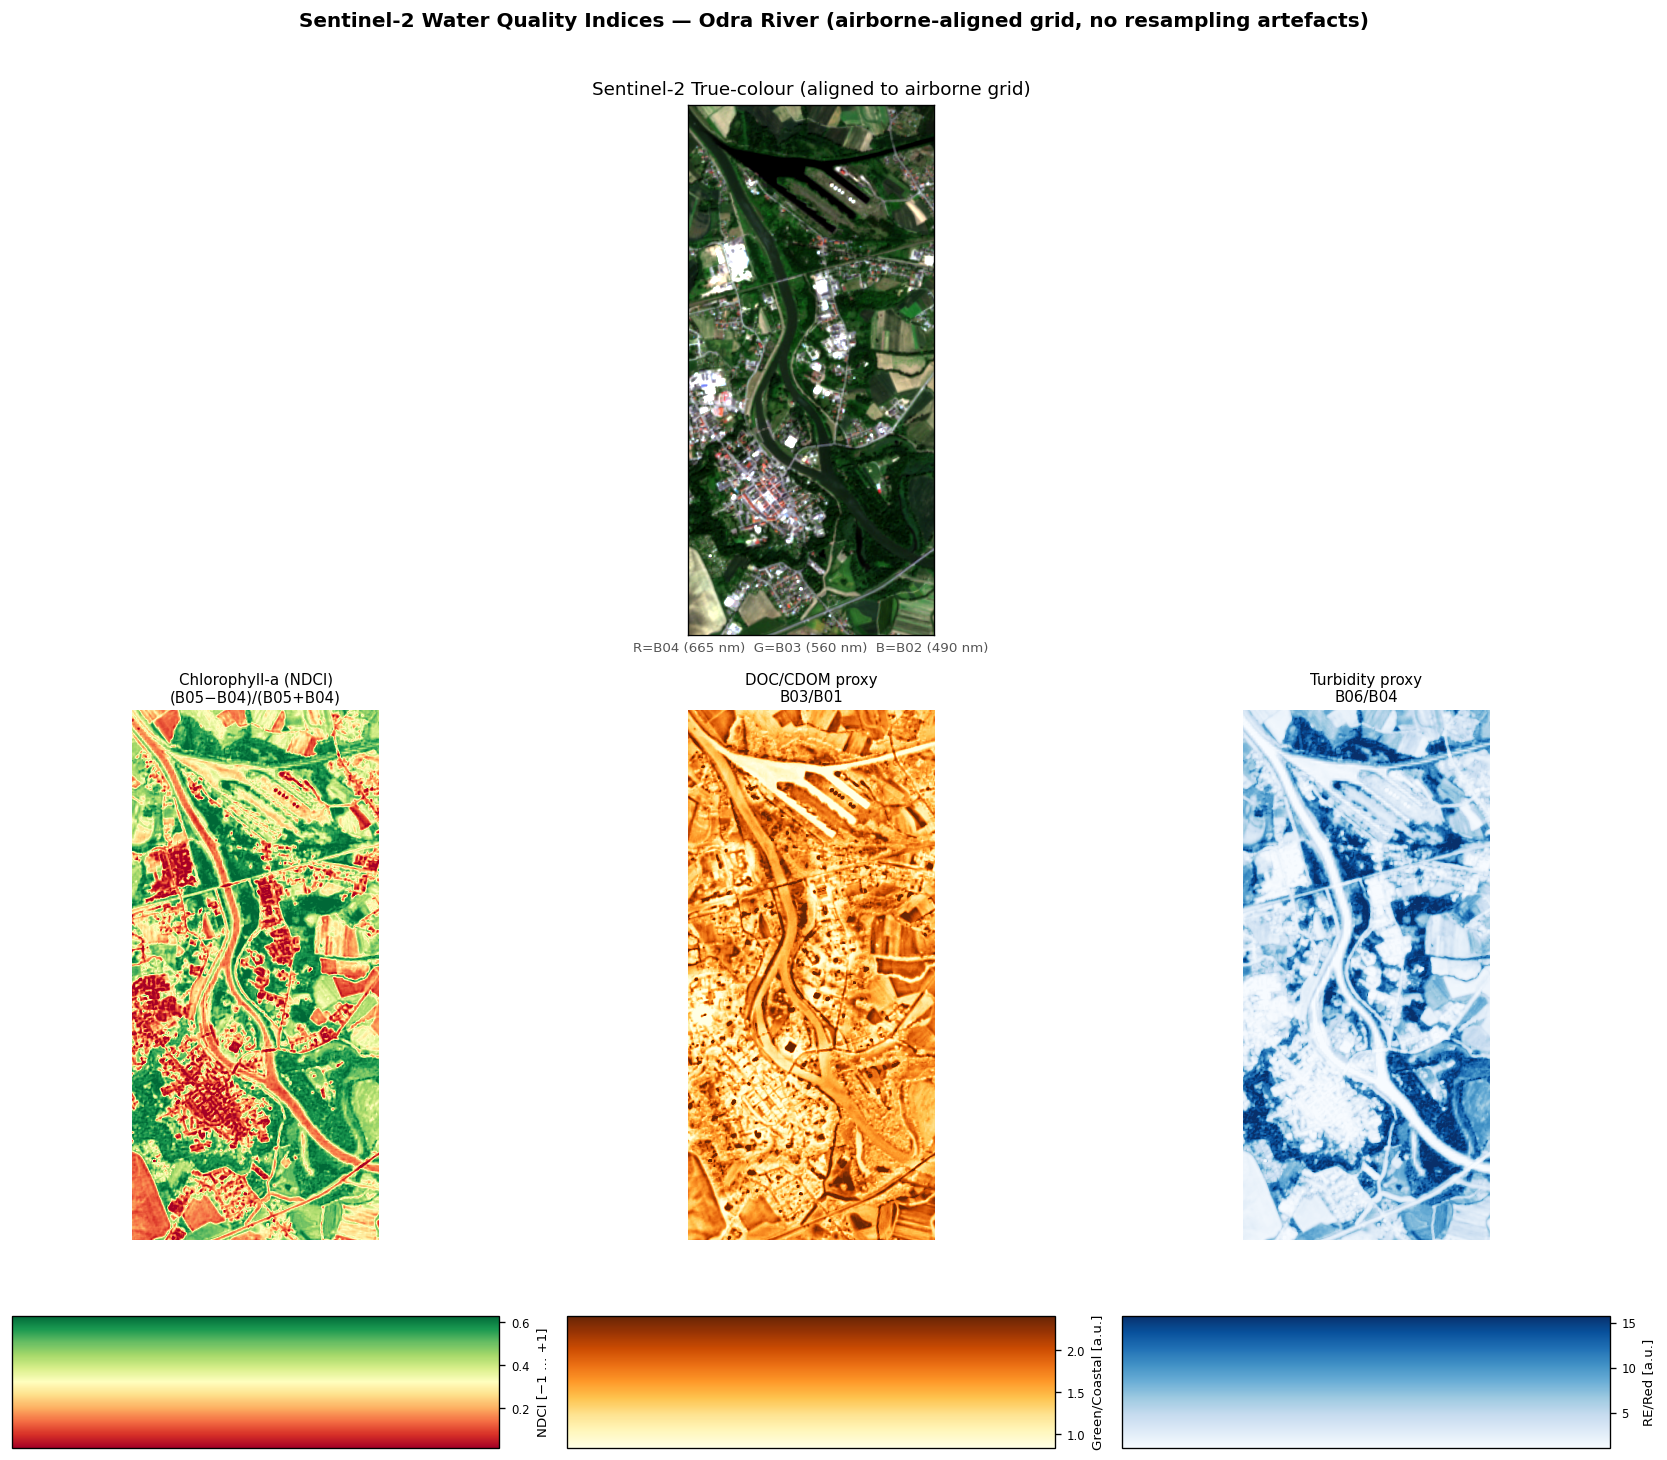

Chl-a (NDCI)          min=-0.4440  median=0.3745  max=0.8688  (n=8,604,300)
DOC/CDOM              min=0.2320  median=1.5594  max=9.0700  (n=8,604,300)
Turbidity             min=0.1379  median=4.8771  max=27.9882  (n=8,604,300)


In [75]:
# ── Sentinel-2 Water Quality Indices (airborne-aligned bands) ─────────────────
#
# All S2 bands are now on the same pixel grid as the airborne cube, so no
# spatial resampling (scipy zoom) is needed here.

def s2b(index_name):
    """Return the warped S2 array for the band assigned to index_name."""
    band = selected_bands.get(index_name)
    return s2_arrays.get(band, np.full((cube_height, cube_width), np.nan))

# Reflectance planes
r_chl_re   = s2b("CHL_RE")     # ~705 nm → B05 rededge1
r_chl_red  = s2b("CHL_RED")    # ~665 nm → B04 red
r_doc_g    = s2b("DOC_GREEN")  # ~560 nm → B03 green
r_doc_b    = s2b("DOC_BLUE")   # ~443 nm → B01 coastal
r_turb_nir = s2b("TURB_NIR")   # ~740 nm → B06 rededge2
r_turb_red = s2b("TURB_RED")   # ~665 nm → B04 red
r_blue     = s2_arrays.get("B02", np.full((cube_height, cube_width), np.nan))

# Water quality indices (reuse helpers from cell 11)
chl_a_s2 = ndvi_like(r_chl_re,  r_chl_red)    # NDCI
doc_s2   = band_ratio(r_doc_g,  r_doc_b)       # Green/Coastal
turb_s2  = band_ratio(r_turb_nir, r_turb_red)  # NIR/Red

# True-colour composite
def _stretch(arr, pct=(2, 98)):
    v = arr[np.isfinite(arr)]
    if v.size == 0:
        return np.zeros_like(arr)
    lo, hi = np.percentile(v, pct)
    hi = max(hi, lo + 1e-6)
    out = np.clip((arr - lo) / (hi - lo), 0, 1)
    out[~np.isfinite(arr)] = 0
    return out

s2_rgb = (np.stack([_stretch(r_chl_red), _stretch(r_doc_g), _stretch(r_blue)],
                    axis=2) * 255).astype(np.uint8)

# Layout identical to the airborne index panel (cell 13)
fig = plt.figure(figsize=(14, 12), dpi=120)
gs  = GridSpec(3, 3, figure=fig, height_ratios=[2, 2, 0.5])
ax_rgb  = fig.add_subplot(gs[0, :])
ax_chl  = fig.add_subplot(gs[1, 0])
ax_doc  = fig.add_subplot(gs[1, 1])
ax_turb = fig.add_subplot(gs[1, 2])
cb_chl  = fig.add_subplot(gs[2, 0])
cb_doc  = fig.add_subplot(gs[2, 1])
cb_turb = fig.add_subplot(gs[2, 2])

ax_rgb.imshow(s2_rgb, interpolation="nearest")
ax_rgb.set_title("Sentinel-2 True-colour (aligned to airborne grid)", fontsize=11, pad=6)
ax_rgb.set_xlabel("R=B04 (665 nm)  G=B03 (560 nm)  B=B02 (490 nm)", fontsize=8, color="#555")
ax_rgb.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plot_index(ax_chl,  chl_a_s2, "Chlorophyll-a (NDCI)\n(B05−B04)/(B05+B04)",
           "RdYlGn", cbar_label="NDCI [−1 … +1]",       cax=cb_chl)
plot_index(ax_doc,  doc_s2,   "DOC/CDOM proxy\nB03/B01",
           "YlOrBr", cbar_label="Green/Coastal [a.u.]", cax=cb_doc)
plot_index(ax_turb, turb_s2,  "Turbidity proxy\nB06/B04",
           "Blues",  cbar_label="RE/Red [a.u.]",         cax=cb_turb)

plt.suptitle("Sentinel-2 Water Quality Indices — Odra River "
             "(airborne-aligned grid, no resampling artefacts)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

for name, arr in [("Chl-a (NDCI)", chl_a_s2),
                  ("DOC/CDOM",     doc_s2),
                  ("Turbidity",    turb_s2)]:
    v = arr[np.isfinite(arr)]
    if v.size:
        print(f"{name:<20}  min={v.min():.4f}  "
              f"median={np.median(v):.4f}  max={v.max():.4f}  (n={v.size:,})")
    else:
        print(f"{name:<20}  no valid pixels")


11. Spectral Angle Mapper (SAM) — airborne reference spectra

Reference pixel counts:
  Clear water    : 411,317 px
  Turbid water   : 2,150,941 px
  Algae-rich     : 2,150,944 px


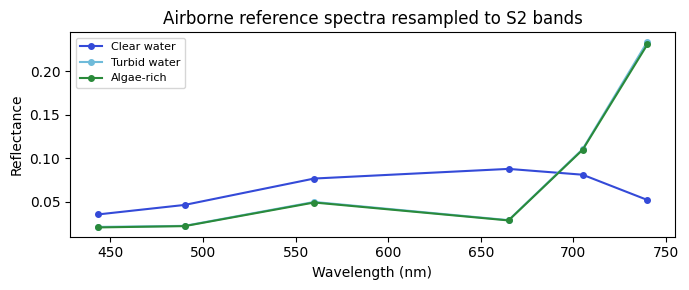

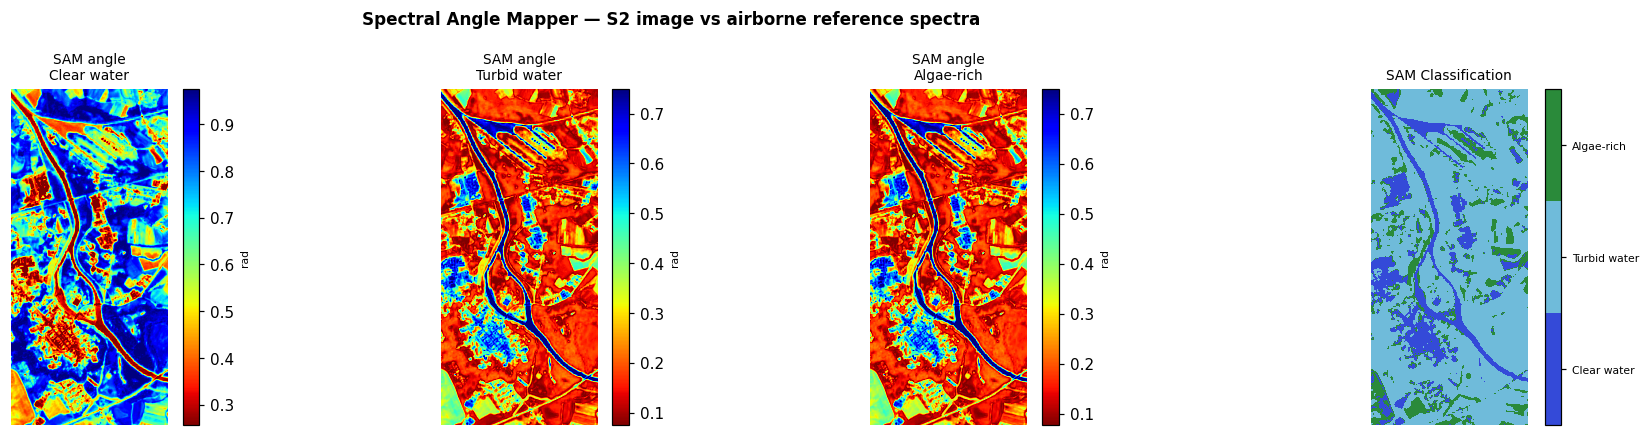

Classification breakdown:
  Clear water    : 1,335,154 px  (15.5 %)
  Turbid water   : 6,120,808 px  (71.1 %)
  Algae-rich     : 1,148,338 px  (13.3 %)


In [76]:
# ── Spectral Angle Mapper (SAM) using airborne reference spectra ──────────────
#
# Approach (adapted from the deforestation / Appalachian mining notebook):
#   1. Use the airborne water-quality index maps (cells 12-13) to isolate
#      representative pixels for three water classes:
#        • Clear water   — low NDCI AND low turbidity
#        • Turbid water  — high turbidity ratio
#        • Algae-rich    — high NDCI (chlorophyll-a)
#   2. Collect their full hyperspectral spectra from the airborne cube and
#      compute per-class median spectra.
#   3. Resample each median spectrum from airborne wavelengths to S2 band
#      wavelengths (nearest-band lookup, same strategy as the deforestation
#      notebook's `ref_spectra` / `np.arccos` pipeline).
#   4. For every S2 pixel compute the spectral angle against each reference.
#   5. Classify by minimum angle.

# ── 1. Define class masks from airborne index maps ───────────────────────────
def _pct(arr, q):
    v = arr[np.isfinite(arr)]
    return float(np.percentile(v, q)) if v.size else 0.0

mask_clear  = (chl_a  < _pct(chl_a,  25)) & (turb < _pct(turb,  25)) \
              & np.isfinite(chl_a) & np.isfinite(turb)
mask_turbid = (turb   > _pct(turb,   75)) & np.isfinite(turb)
mask_algae  = (chl_a  > _pct(chl_a,  75)) & np.isfinite(chl_a)

print("Reference pixel counts:")
for label_, mask_ in [("Clear water", mask_clear),
                       ("Turbid water", mask_turbid),
                       ("Algae-rich",   mask_algae)]:
    print(f"  {label_:<15}: {mask_.sum():,} px")

# ── 2. Extract airborne spectra for each class ───────────────────────────────
np.random.seed(42)

def sample_spectra(cube, mask, max_px=2000):
    """Return (N, bands) float32 reflectance array from mask pixels."""
    rows_idx, cols_idx = np.where(mask)
    if rows_idx.size == 0:
        return np.zeros((1, cube.bands), dtype=np.float32)
    sel = np.random.choice(rows_idx.size,
                            min(max_px, rows_idx.size), replace=False)
    out = np.stack(
        [cube.data[:, rows_idx[i], cols_idx[i]].astype(np.float32)
         / cube.scale_factor
         for i in sel], axis=0
    )
    return out

class_names   = ["Clear water", "Turbid water", "Algae-rich"]
class_masks   = [mask_clear,    mask_turbid,     mask_algae  ]
class_colors  = ["#344AD8",     "#6FBBDA",       "#2A8A3A"   ]

air_spectra = {n: sample_spectra(cube, m) for n, m in zip(class_names, class_masks)}

# ── 3. Resample median airborne spectra to S2 band wavelengths ───────────────
s2_wl_names = sorted(
    [b for b in set(selected_bands.values()) if b in s2_arrays],
    key=lambda b: S2_BAND_WAVELENGTHS[b]
)
s2_wl_vals = np.array([S2_BAND_WAVELENGTHS[b] for b in s2_wl_names])

def resample_to_s2(spectra_air, air_wl, s2_wl):
    """Map median airborne spectrum onto S2 wavelengths (nearest-band)."""
    med = np.nanmedian(spectra_air, axis=0)
    return np.array([med[np.argmin(np.abs(air_wl - w))] for w in s2_wl])

ref_s2 = {n: resample_to_s2(air_spectra[n], cube.wavelengths, s2_wl_vals)
           for n in class_names}

# Quick sanity plot of reference spectra
fig_ref, ax_ref = plt.subplots(figsize=(7, 3), dpi=100)
for n, col in zip(class_names, class_colors):
    ax_ref.plot(s2_wl_vals, ref_s2[n], "o-", color=col, label=n, lw=1.5, ms=4)
ax_ref.set_xlabel("Wavelength (nm)"); ax_ref.set_ylabel("Reflectance")
ax_ref.set_title("Airborne reference spectra resampled to S2 bands")
ax_ref.legend(fontsize=8); plt.tight_layout(); plt.show()

# ── 4. Build S2 pixel matrix ─────────────────────────────────────────────────
s2_stack = np.stack([s2_arrays[b] for b in s2_wl_names], axis=2)   # H × W × n_bands
H, W, n_b = s2_stack.shape
s2_flat   = s2_stack.reshape(-1, n_b).astype(np.float64)

# ── 5. Compute spectral angles (identical formula to deforestation notebook) ─
def spectral_angle_map(pixels, ref_vec):
    """Return per-pixel spectral angle (rad) — mirrors the SAM in deforestation nb."""
    dot    = pixels @ ref_vec                                          # (N,)
    norm_p = np.linalg.norm(pixels, axis=1)                            # (N,)
    norm_r = np.linalg.norm(ref_vec)
    denom  = norm_p * norm_r
    cos_a  = np.where(denom > 0, dot / denom, 0.0)
    return np.arccos(np.clip(cos_a, -1.0, 1.0))

sam_maps = {n: spectral_angle_map(s2_flat, ref_s2[n]).reshape(H, W)
             for n in class_names}

# ── 6. Classify by minimum angle ─────────────────────────────────────────────
angle_stack = np.stack([sam_maps[n] for n in class_names], axis=0)   # n_cls × H × W
best_cls    = np.argmin(angle_stack, axis=0).astype(np.float32)       # H × W
nodata_s2   = ~np.isfinite(s2_stack).all(axis=2)
best_cls[nodata_s2] = np.nan

# ── 7. Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(class_names) + 1,
                          figsize=(18, 4), dpi=110,
                          gridspec_kw={"width_ratios": [1]*len(class_names) + [1.15]})

for i, (n, ax) in enumerate(zip(class_names, axes[:-1])):
    m = sam_maps[n]
    vlo, vhi = np.nanpercentile(m, [2, 98])
    im = ax.imshow(m, cmap="jet_r", vmin=vlo, vmax=vhi, interpolation="nearest")
    ax.set_title(f"SAM angle\n{n}", fontsize=9); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.038, pad=0.03).set_label("rad", fontsize=7)

sam_cmap = mcolors.ListedColormap(class_colors)
im_cls = axes[-1].imshow(best_cls, cmap=sam_cmap,
                          vmin=-0.5, vmax=len(class_names)-0.5,
                          interpolation="nearest")
axes[-1].set_title("SAM Classification", fontsize=9); axes[-1].axis("off")
cbar = plt.colorbar(im_cls, ax=axes[-1], fraction=0.038, pad=0.03,
                     ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names, fontsize=7)

plt.suptitle("Spectral Angle Mapper — S2 image vs airborne reference spectra",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

total_valid = (~nodata_s2).sum()
print("Classification breakdown:")
for i, n in enumerate(class_names):
    px = int(np.sum(best_cls == i))
    print(f"  {n:<15}: {px:>8,} px  ({100*px/total_valid:.1f} %)")


12. Cross-calibration of Sentinel-2 using airborne reflectance

Nearest airborne band for each S2 band:
  B01 (443 nm)  ↔  airborne band 10 (442.9 nm)
  B02 (490 nm)  ↔  airborne band 25 (490.9 nm)
  B03 (560 nm)  ↔  airborne band 47 (561.2 nm)
  B04 (665 nm)  ↔  airborne band 79 (663.5 nm)
  B05 (705 nm)  ↔  airborne band 92 (705.0 nm)
  B06 (740 nm)  ↔  airborne band 103 (740.2 nm)


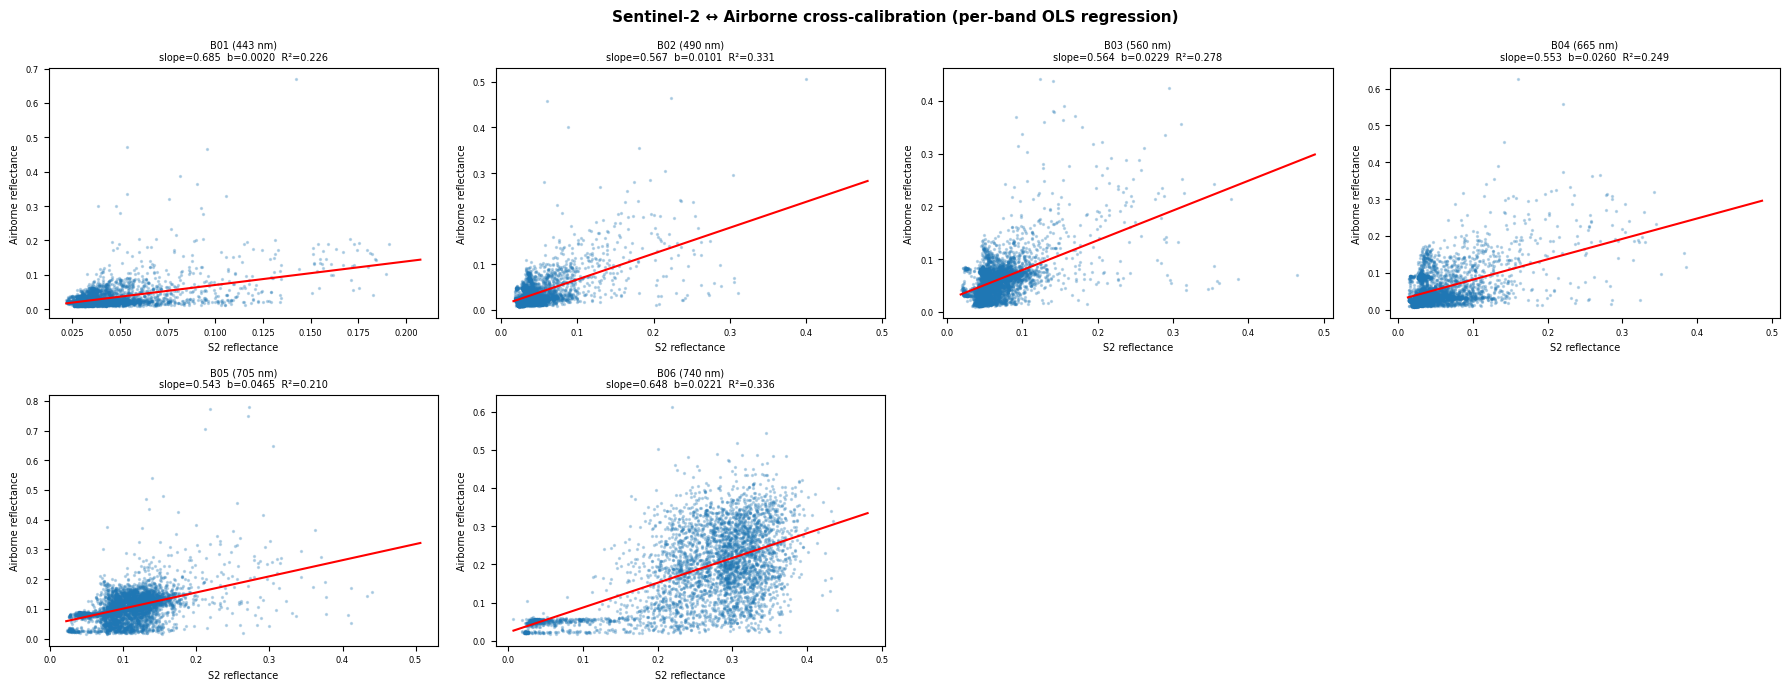


Band     λ (nm)     slope    intercept      R²
B01         443 nm    0.6847      0.00195   0.226
B02         490 nm    0.5668      0.01015   0.331
B03         560 nm    0.5640      0.02291   0.278
B04         665 nm    0.5535      0.02598   0.249
B05         705 nm    0.5429      0.04655   0.210
B06         740 nm    0.6482      0.02212   0.336


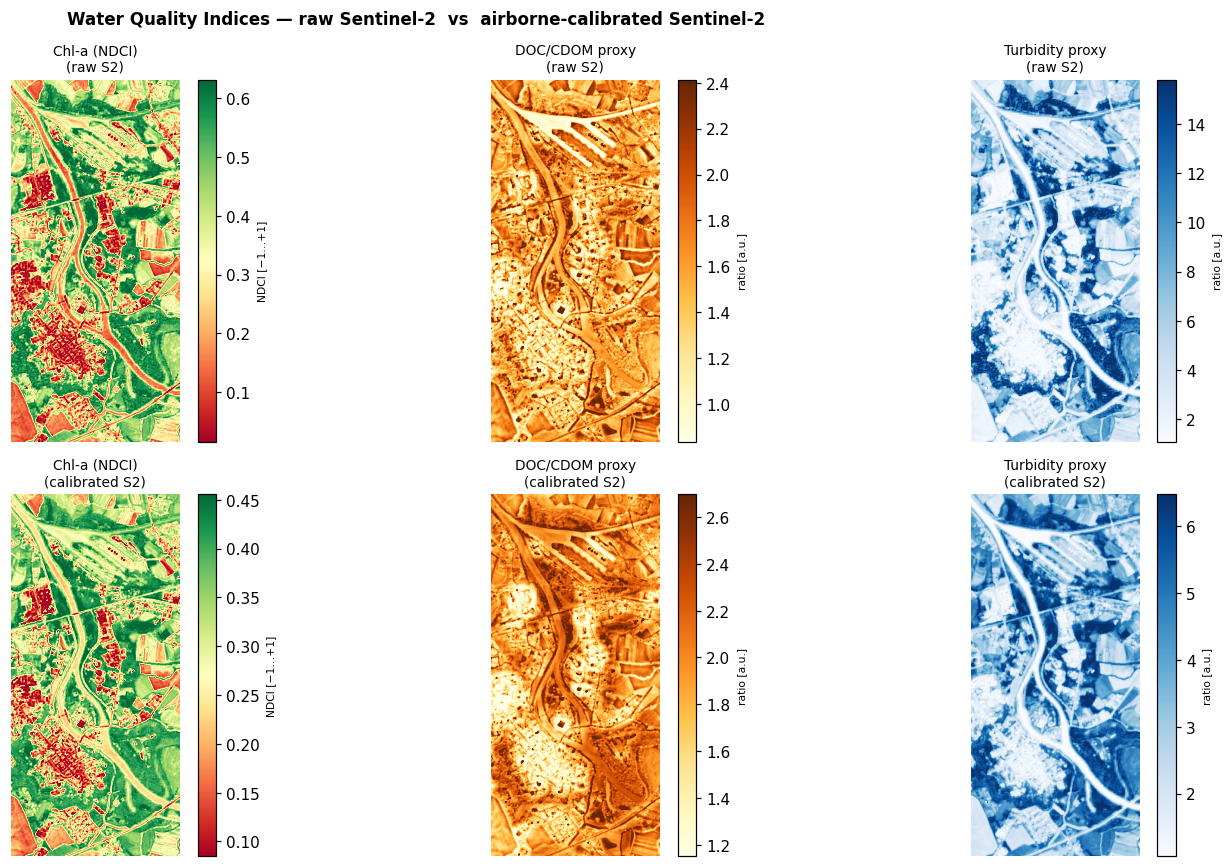


Index statistics — calibrated vs raw:
  Chl-a     raw  med=0.3745  cal  med=0.3268  Δmed=-0.0477
  DOC       raw  med=1.5594  cal  med=1.9778  Δmed=+0.4185
  Turb      raw  med=4.8771  cal  med=3.3936  Δmed=-1.4835


In [77]:
# ── Cross-calibration of Sentinel-2 using airborne reflectance ───────────────
#
# Rationale
# ---------
# The airborne hyperspectral scanner delivers high-quality at-surface
# reflectance in the same scene as the S2 overpass.  Sentinel-2 L2A data
# already has an atmospheric correction applied, but residual offsets remain
# due to (i) differences in sensor spectral response functions, (ii) the
# gap between the airborne acquisition and the S2 overpass date, and (iii)
# adjacency effects. A per-band linear regression ties S2 radiance to
# airborne truth — an established vicarious / empirical-line calibration.
#
# Method
# ------
# For each S2 band B_i at wavelength λ_i:
#   1. Find the nearest airborne band to λ_i.
#   2. Collect all spatially coincident, finite, positive pixel pairs.
#   3. Fit:  ρ_airborne(λ_i)  =  a_i × ρ_S2(B_i)  +  b_i   (OLS)
#   4. Apply the regression coefficients image-wide to produce
#      calibrated S2 reflectance ρ_S2_cal(B_i).
# Recompute the water-quality indices on the calibrated bands and compare.

# ── Step 1: build per-band airborne reference images ─────────────────────────
# The airborne cube and the S2 arrays already share the same pixel grid
# (cube_height × cube_width), so the comparison is pixel-exact.

print("Nearest airborne band for each S2 band:")
air_at_s2 = {}        # band_name → (H, W) airborne reflectance
for b in s2_wl_names:
    wl      = S2_BAND_WAVELENGTHS[b]
    air_idx = cube.nearest_band(wl)
    air_arr = cube.band_float(air_idx) / cube.scale_factor   # lines × samples
    air_at_s2[b] = air_arr
    print(f"  {b} ({wl} nm)  ↔  airborne band {air_idx+1} "
          f"({cube.wavelengths[air_idx]:.1f} nm)")

# ── Step 2: fit one linear regression per band ────────────────────────────────
calibration_coefs = {}    # band → (slope, intercept, R²)
s2_calibrated     = {}    # band → calibrated reflectance array

n_cols = min(len(s2_wl_names), 4)
n_rows = int(np.ceil(len(s2_wl_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(4.5 * n_cols, 3.5 * n_rows), dpi=100)
axes = np.array(axes).flatten()

for ax_i, b in enumerate(s2_wl_names):
    s2_arr  = s2_arrays[b]
    air_arr = air_at_s2[b]

    valid = (np.isfinite(s2_arr) & np.isfinite(air_arr)
             & (s2_arr > 0)      & (air_arr > 0))
    n_valid = int(valid.sum())

    if n_valid < 50:
        print(f"  {b}: only {n_valid} valid pixels — using identity (slope=1, b=0).")
        calibration_coefs[b] = (1.0, 0.0, np.nan)
        s2_calibrated[b] = s2_arr.copy()
        axes[ax_i].set_visible(False)
        continue

    x = s2_arr[valid].reshape(-1, 1)     # S2  as predictor
    y = air_arr[valid].reshape(-1, 1)    # airborne as ground truth

    xv = x.ravel()
    yv = y.ravel()
    Xd = np.column_stack([xv, np.ones(n_valid)])
    coef, _, _, _ = np.linalg.lstsq(Xd, yv, rcond=None)
    a, bi_ = float(coef[0]), float(coef[1])
    y_hat = Xd @ coef
    ss_res = float(np.sum((yv - y_hat) ** 2))
    ss_tot = float(np.sum((yv - yv.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
    calibration_coefs[b] = (a, bi_, r2)

    # Apply calibration image-wide
    cal = a * s2_arr + bi_
    cal[cal < 0] = 0.0
    cal[~np.isfinite(s2_arr)] = np.nan
    s2_calibrated[b] = cal

    # Scatter plot (sub-sampled for speed)
    n_plot = min(4000, n_valid)
    idx_p  = np.random.choice(n_valid, n_plot, replace=False)
    ax = axes[ax_i]
    ax.scatter(x[idx_p], y[idx_p], s=2, alpha=0.25, c="#1f77b4", rasterized=True)
    x_line = np.array([[x.min()], [x.max()]])
    ax.plot(x_line.ravel(), a * x_line.ravel() + bi_, "r-", lw=1.5)
    ax.set_xlabel("S2 reflectance",       fontsize=7)
    ax.set_ylabel("Airborne reflectance", fontsize=7)
    ax.set_title(f"{b} ({S2_BAND_WAVELENGTHS[b]} nm)\n"
                 f"slope={a:.3f}  b={bi_:.4f}  R²={r2:.3f}", fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes[len(s2_wl_names):]:
    ax.set_visible(False)

plt.suptitle("Sentinel-2 ↔ Airborne cross-calibration (per-band OLS regression)",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"\n{'Band':<6}  {'λ (nm)':>7}  {'slope':>8}  {'intercept':>11}  {'R²':>6}")
for b, (a, bi_, r2) in calibration_coefs.items():
    r2_str = f"{r2:.3f}" if not np.isnan(r2) else "  N/A"
    print(f"{b:<6}  {S2_BAND_WAVELENGTHS[b]:>7} nm  {a:>8.4f}  {bi_:>11.5f}  {r2_str:>6}")

# ── Step 3: recompute water-quality indices with calibrated S2 ────────────────
def s2_cal(index_name):
    b = selected_bands.get(index_name)
    return s2_calibrated.get(b, np.full((cube_height, cube_width), np.nan))

chl_a_cal = ndvi_like(s2_cal("CHL_RE"),   s2_cal("CHL_RED"))
doc_cal   = band_ratio(s2_cal("DOC_GREEN"), s2_cal("DOC_BLUE"))
turb_cal  = band_ratio(s2_cal("TURB_NIR"),  s2_cal("TURB_RED"))

# ── Step 4: side-by-side comparison — raw S2 vs calibrated S2 ─────────────────
fig2, axs2 = plt.subplots(2, 3, figsize=(15, 8), dpi=110)
pairs = [
    (chl_a_s2, chl_a_cal, "Chl-a (NDCI)",    "RdYlGn", "NDCI [−1…+1]"),
    (doc_s2,   doc_cal,   "DOC/CDOM proxy",   "YlOrBr", "ratio [a.u.]"),
    (turb_s2,  turb_cal,  "Turbidity proxy",  "Blues",  "ratio [a.u.]"),
]
for col, (raw, cal, title, cmap, clbl) in enumerate(pairs):
    for row, (arr, suffix) in enumerate([(raw, "raw S2"), (cal, "calibrated S2")]):
        v = arr[np.isfinite(arr)]
        vlo, vhi = (np.percentile(v, [2, 98]) if v.size else (0, 1))
        im = axs2[row, col].imshow(arr, cmap=cmap, vmin=vlo, vmax=vhi,
                                    interpolation="nearest")
        axs2[row, col].set_title(f"{title}\n({suffix})", fontsize=9)
        axs2[row, col].axis("off")
        plt.colorbar(im, ax=axs2[row, col],
                     fraction=0.035, pad=0.03).set_label(clbl, fontsize=7)

plt.suptitle("Water Quality Indices — raw Sentinel-2  vs  airborne-calibrated Sentinel-2",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nIndex statistics — calibrated vs raw:")
for name, raw, cal in [("Chl-a", chl_a_s2, chl_a_cal),
                        ("DOC",   doc_s2,   doc_cal),
                        ("Turb",  turb_s2,  turb_cal)]:
    vr = raw[np.isfinite(raw)]; vc = cal[np.isfinite(cal)]
    print(f"  {name:<8}  raw  med={np.median(vr):.4f}  "
          f"cal  med={np.median(vc):.4f}  Δmed={np.median(vc)-np.median(vr):+.4f}")
